# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [1]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [2]:
# !mkdir -p data
# !wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

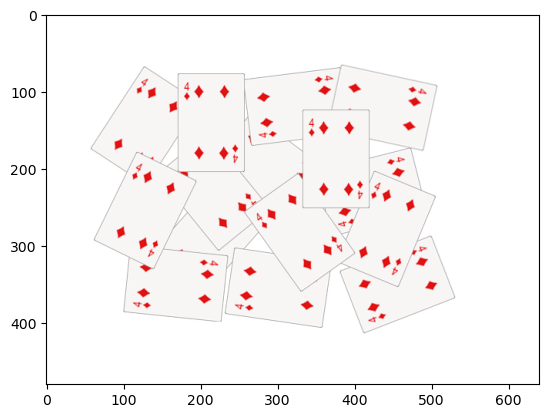

In [3]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

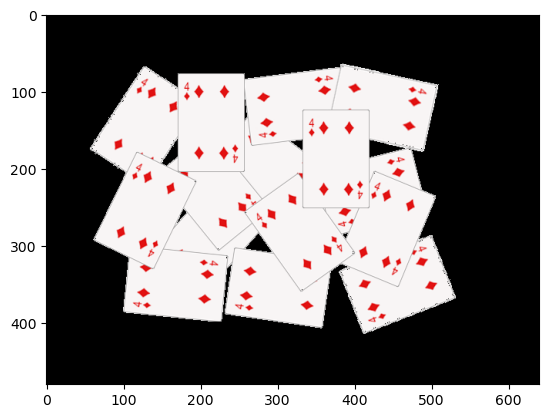

In [4]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

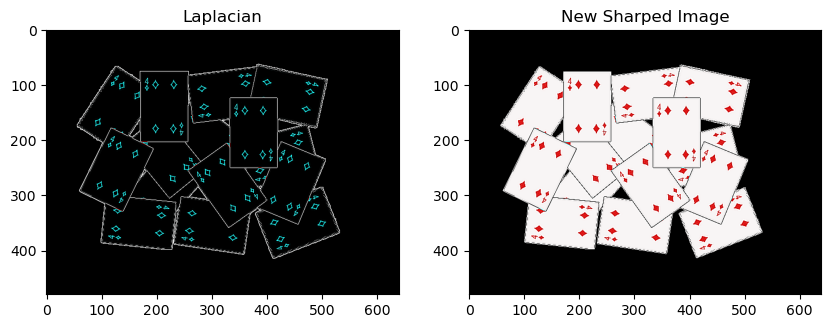

In [5]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

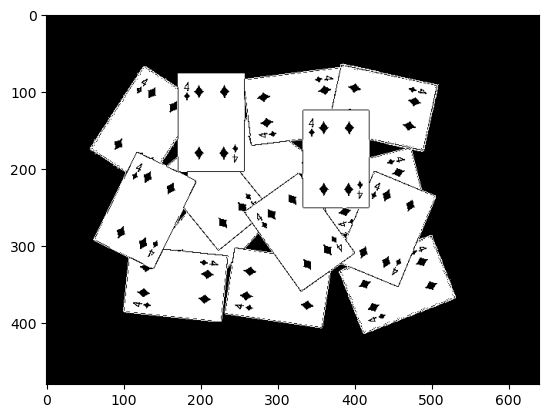

In [6]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

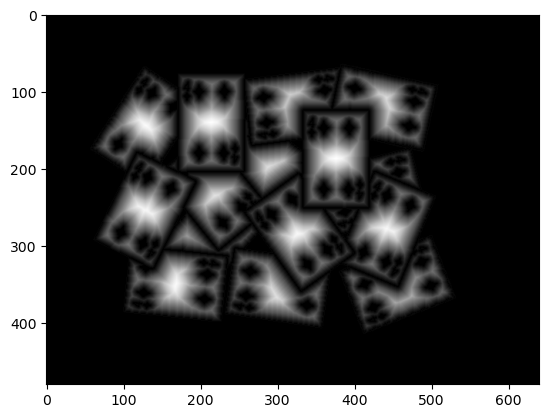

In [7]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

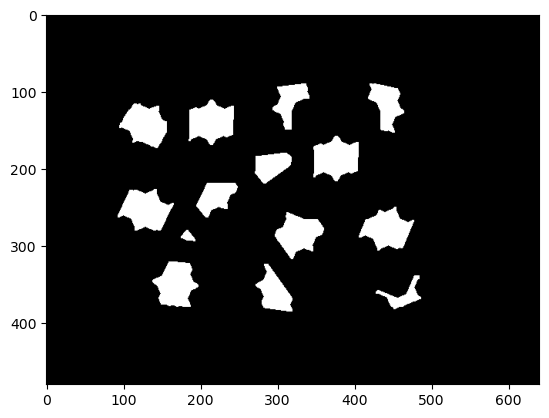

In [8]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

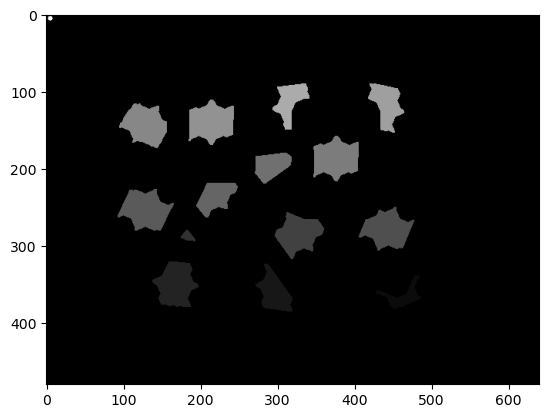

In [9]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

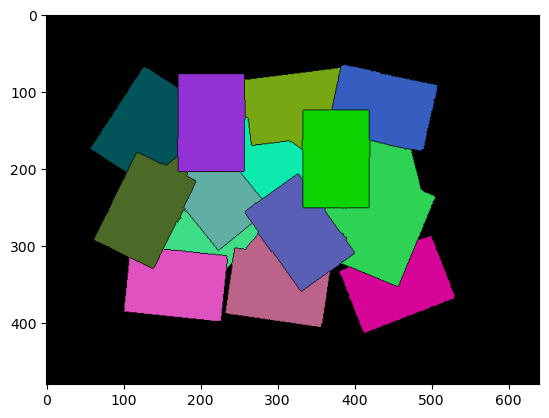

In [10]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

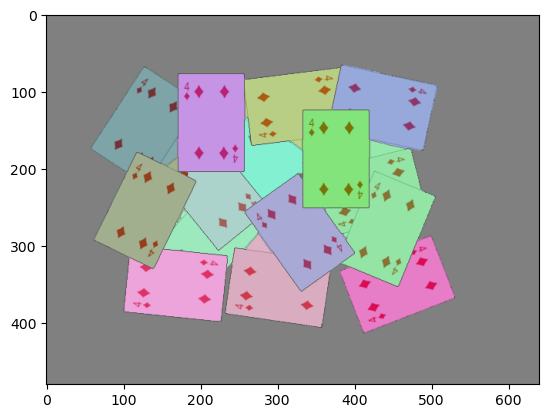

In [11]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

In [40]:
def count_fingers(image):
    gray = cv2.GaussianBlur(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY), (7, 7), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if gray[mask > 0].mean() < gray[mask == 0].mean():
        mask = cv2.bitwise_not(mask)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    contour = max(cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea)
    hull_idx = cv2.convexHull(contour, returnPoints=False)
    hull = cv2.convexHull(contour)
    defects = cv2.convexityDefects(contour, hull_idx)
    vis, count = image.copy(), 0
    cv2.drawContours(vis, [contour], -1, (0, 255, 0), 2)
    cv2.drawContours(vis, [hull], -1, (255, 255, 0), 2)
    if defects is not None:
        for s, e, f, d in defects[:, 0]:
            a, b, c = contour[s, 0], contour[e, 0], contour[f, 0]
            ac, bc, ab = np.linalg.norm(a - c), np.linalg.norm(b - c), np.linalg.norm(a - b)
            angle = np.degrees(np.arccos(np.clip((ac**2 + bc**2 - ab**2) / (2 * ac * bc), -1, 1)))
            if angle < 90 and d > 20 * 256 and c[1] < 0.8 * image.shape[0]:
                count += 1
                cv2.circle(vis, tuple(c), 7, (255, 0, 255), -1)
                cv2.line(vis, tuple(a), tuple(c), (0, 255, 255), 2)
                cv2.line(vis, tuple(b), tuple(c), (0, 255, 255), 2)
    if count == 0:
        _, _, w, h = cv2.boundingRect(contour)
        return mask, vis, int(h / w > 1.35)
    return mask, vis, min(count + 1, 5)


Количество пальцев: 0


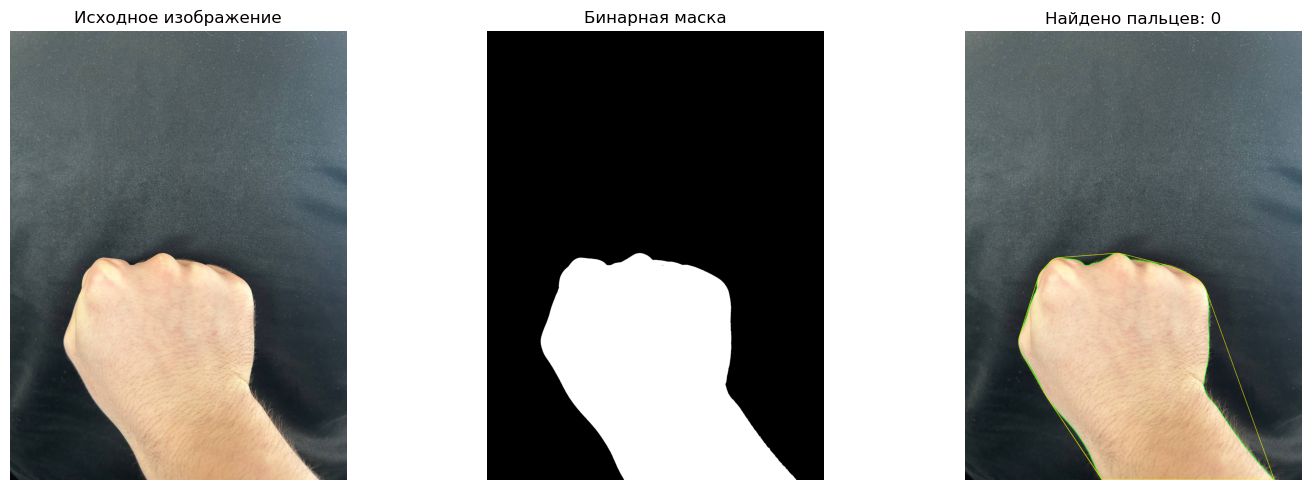

In [42]:
img = cv2.cvtColor(cv2.imread("data/fing0.jpg"), cv2.COLOR_BGR2RGB)
mask, vis, n_fingers = count_fingers(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Исходное изображение")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Бинарная маска")
axes[2].imshow(vis)
axes[2].set_title(f"Найдено пальцев: {n_fingers}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Количество пальцев:", n_fingers)


Количество пальцев: 1


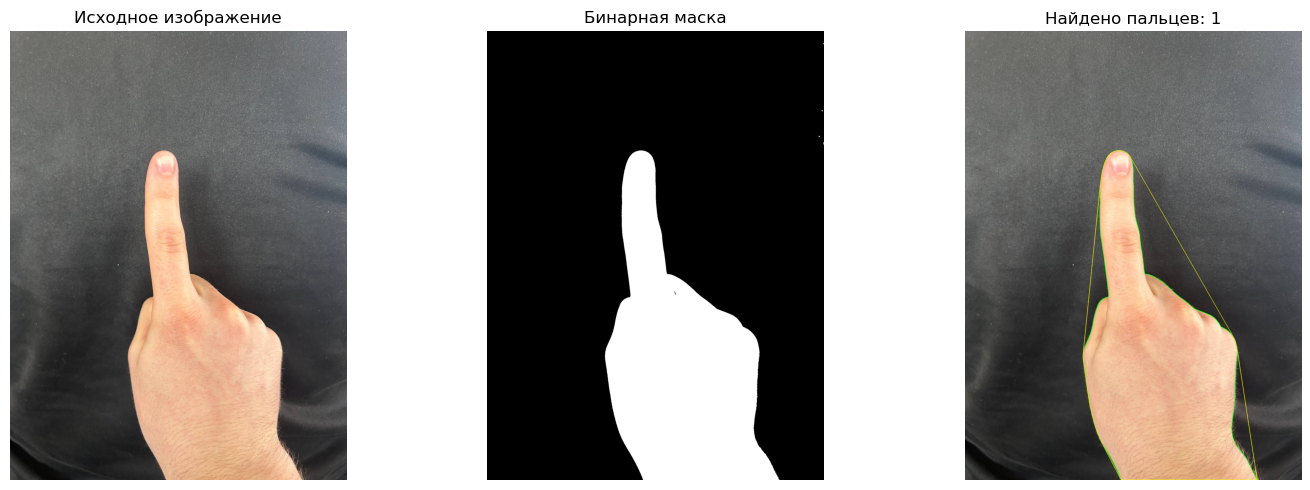

In [43]:
img = cv2.cvtColor(cv2.imread("data/fing1.jpg"), cv2.COLOR_BGR2RGB)
mask, vis, n_fingers = count_fingers(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Исходное изображение")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Бинарная маска")
axes[2].imshow(vis)
axes[2].set_title(f"Найдено пальцев: {n_fingers}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Количество пальцев:", n_fingers)


Количество пальцев: 2


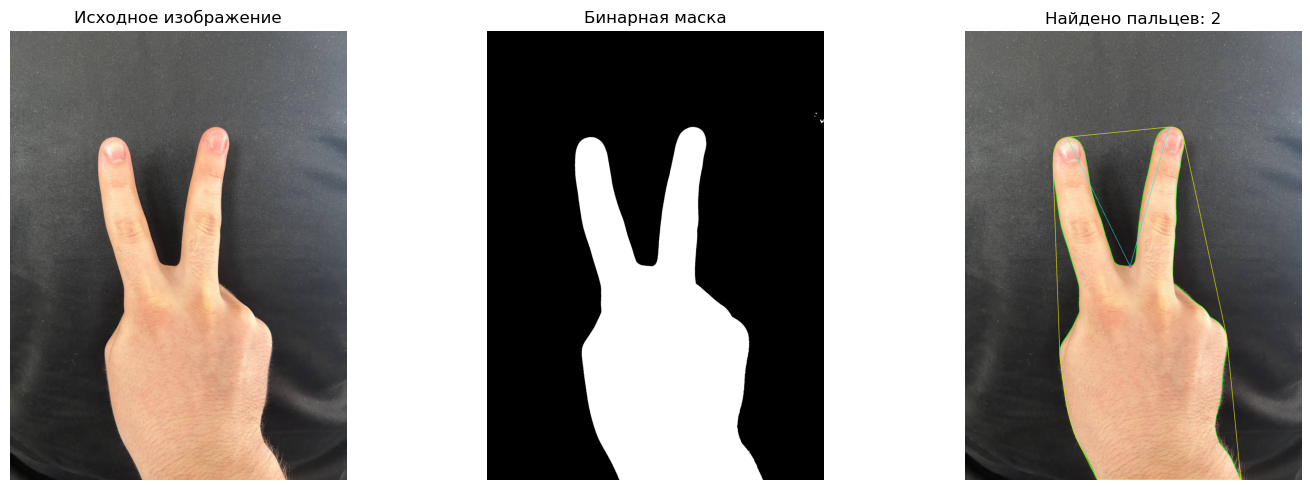

In [44]:
img = cv2.cvtColor(cv2.imread("data/fing2.jpg"), cv2.COLOR_BGR2RGB)
mask, vis, n_fingers = count_fingers(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Исходное изображение")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Бинарная маска")
axes[2].imshow(vis)
axes[2].set_title(f"Найдено пальцев: {n_fingers}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Количество пальцев:", n_fingers)


Количество пальцев: 3


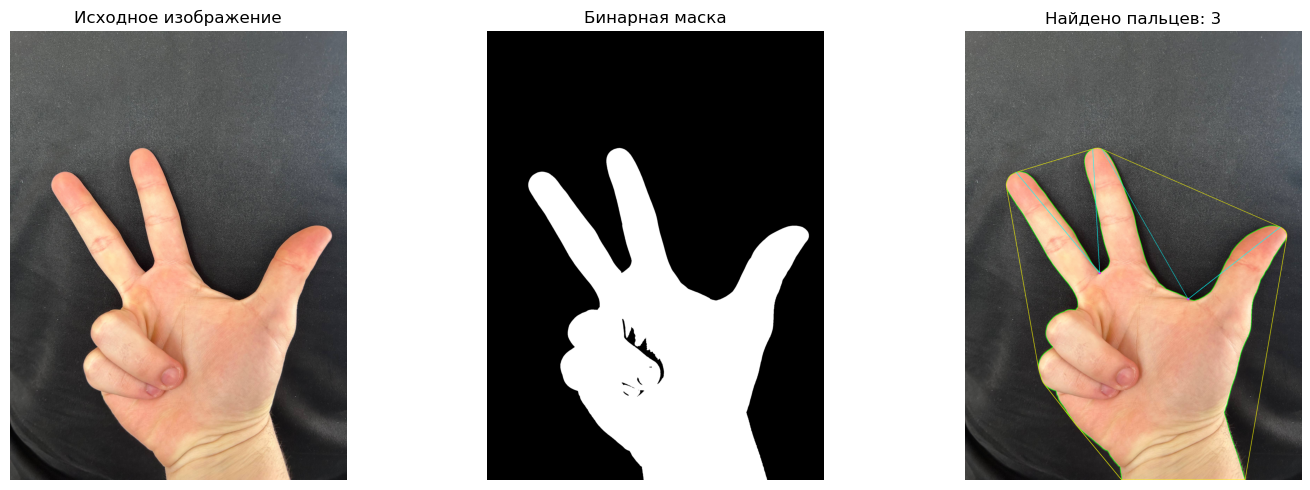

In [45]:
img = cv2.cvtColor(cv2.imread("data/fing3.jpg"), cv2.COLOR_BGR2RGB)
mask, vis, n_fingers = count_fingers(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Исходное изображение")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Бинарная маска")
axes[2].imshow(vis)
axes[2].set_title(f"Найдено пальцев: {n_fingers}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Количество пальцев:", n_fingers)


Количество пальцев: 5


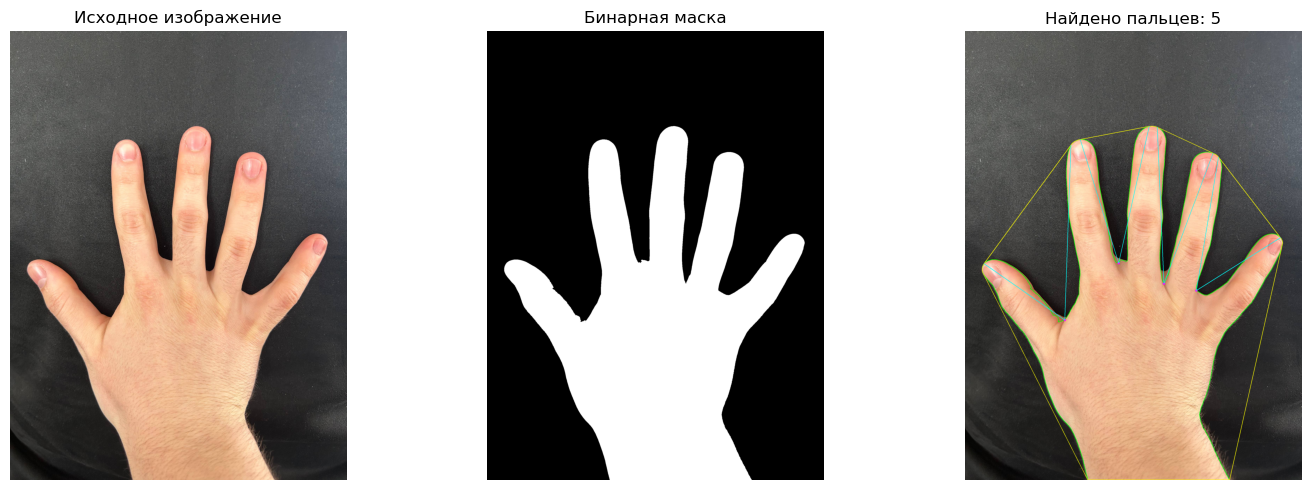

In [47]:
img = cv2.cvtColor(cv2.imread("data/fing5.jpg"), cv2.COLOR_BGR2RGB)
mask, vis, n_fingers = count_fingers(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title("Исходное изображение")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Бинарная маска")
axes[2].imshow(vis)
axes[2].set_title(f"Найдено пальцев: {n_fingers}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Количество пальцев:", n_fingers)
